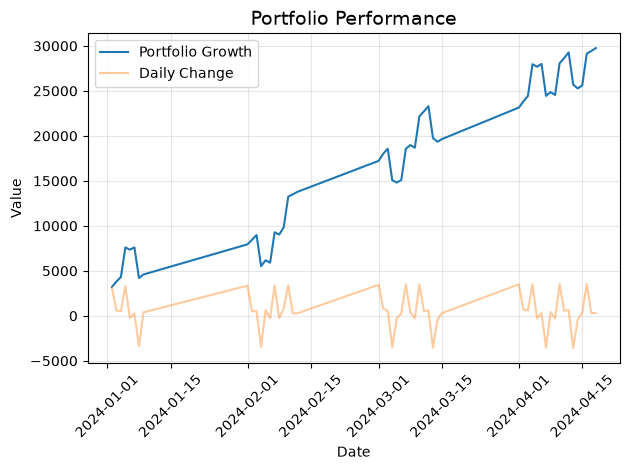

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DB_FILE = Path("data/stocks.db")
if not DB_FILE.exists():
	DB_FILE = Path.cwd().parent / "data" / "stocks.db"
if not DB_FILE.exists():
	raise FileNotFoundError(f"Database file not found: {DB_FILE}")

# Connect database
connection = sqlite3.connect(DB_FILE)

# Load portfolio data
query = """
SELECT date, SUM(net_value) as
daily_value
FROM transactions
Group BY date
ORDER BY date
"""

df = pd.read_sql(query, connection)
df["date"] = pd.to_datetime(df["date"])

# Calculate portfolio growth
df["cumulative"] = df["daily_value"].cumsum()
df.head()

# Plot
plt.plot(df["date"], df["cumulative"], label="Portfolio Growth")

# Daily Change
plt.plot(df["date"], df["daily_value"], label="Daily Change", alpha=0.4)

plt.xticks(rotation=45)

plt.title("Portfolio Performance", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()

plt.show()

